# Inventory Dataset Preprocessing

## Library Imports

In [1]:
# To handle dataframe objects
import pandas as pd

# To create temporary csv files for inspection
import tempfile

# To handle api requests and responses
import requests

# To suppress warnings
import warnings

# To make visualisations
import matplotlib.pyplot as plt

In [2]:
# Suppress all warnings while executing the code
warnings.filterwarnings('ignore')

## Helper Functions

### Utility Functions

In [3]:
def MissingValueSummary(df):
    print('Number of instances = %d' % (df.shape[0]))

    print('\nMissing Values Summary:')
    print('=' * 50)

    # Create a summary DataFrame
    missing_data = pd.DataFrame({
        'Column': df.columns,
        'Missing_Values': [df[col].isnull().sum() for col in df.columns],
        'Percent_Missing': [(df[col].isnull().sum() / len(df)) * 100 
                        for col in df.columns]
    })

    # Print formatted table
    print(missing_data.to_string(index=False, formatters={
        'Percent_Missing': '{:.2f}%'.format
    }))

In [4]:
def TempCSVFile(df):
    temp_csv = tempfile.NamedTemporaryFile(mode='w', suffix='.csv', delete=False)
    df.to_csv(temp_csv.name, index=False)
    temp_csv.close()

    print(f"Data exported to: {temp_csv.name}")

In [5]:
def visualize_unique_values(df, column_name, max_categories=10, figsize=(12, 8)):
    """
    Create visualizations for unique values in a column
    
    Parameters:
    - df: DataFrame
    - column_name: Column to analyze
    - max_categories: Maximum number of categories to show individually in pie chart
    - figsize: Figure size for plots
    """
    
    # Get value counts
    value_counts = df[column_name].value_counts(dropna=False)
    total = len(df)
    
    # Replace NaN with "Missing" for display
    value_counts_display = value_counts.copy()
    value_counts_display.index = value_counts_display.index.fillna('Missing')
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(f'Analysis of "{column_name}" Column', fontsize=16, fontweight='bold')
    
    # --- PIE CHART (Left) ---
    ax1 = axes[0]
    
    # If too many categories, group small ones as "Other"
    if len(value_counts) > max_categories:
        main_categories = value_counts_display.head(max_categories - 1)
        other_sum = value_counts_display.tail(len(value_counts) - (max_categories - 1)).sum()
        
        pie_data = pd.concat([main_categories, pd.Series({'Other': other_sum})])
        pie_labels = pie_data.index.tolist()
        pie_values = pie_data.values
        
        # Create explode effect for "Other"
        explode = [0.05] * len(pie_labels)
        if 'Other' in pie_labels:
            explode[pie_labels.index('Other')] = 0.1
    else:
        pie_labels = value_counts_display.index.tolist()
        pie_values = value_counts_display.values
        explode = [0.05] * len(pie_labels)
    
    # Create pie chart
    wedges, texts, autotexts = ax1.pie(
        pie_values, 
        labels=pie_labels,
        autopct='%1.1f%%',
        startangle=90,
        explode=explode,
        shadow=True,
        textprops={'fontsize': 10}
    )
    
    # Improve autopct text
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    ax1.set_title(f'Distribution of {column_name}\n({total} total items)', fontsize=12, fontweight='bold')
    ax1.axis('equal')  # Equal aspect ratio ensures pie is drawn as circle
    
    # --- BAR CHART (Right) ---
    ax2 = axes[1]
    
    # Show top categories in bar chart
    top_n = min(15, len(value_counts_display))
    top_values = value_counts_display.head(top_n)
    
    bars = ax2.barh(range(len(top_values)), top_values.values)
    ax2.set_yticks(range(len(top_values)))
    ax2.set_yticklabels(top_values.index)
    ax2.invert_yaxis()  # Highest value at top
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax2.text(width + (width * 0.01), bar.get_y() + bar.get_height()/2,
                f'{width:,} ({width/total*100:.1f}%)',
                va='center', fontsize=9, fontweight='bold')
    
    ax2.set_xlabel('Number of Items')
    ax2.set_title(f'Top {top_n} Values in {column_name}', fontsize=12, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3, linestyle='--')
    
    # Adjust layout and display
    plt.tight_layout()
    plt.show()
    
    # Return the value counts for further analysis
    return value_counts

### API functions

In [6]:
# This function fetches the author, publisher, edition year, most recent edition, and edition location from the title alone
def fetch_from_openlibrary(title: str) -> dict:
    """Fetch from OpenLibrary API (no API key required)"""
    try:
        url = f"https://openlibrary.org/search.json?title={requests.utils.quote(title)}&limit=1"
        response = requests.get(url, timeout=5)
        data = response.json()
        
        if data.get('num_found', 0) == 0:
            return {}
        
        book = data['docs'][0]
        
        return {
            'author': ', '.join(book.get('author_name')),
            'publisher': ', '.join(book.get('publisher'))[:100],
            'year': book.get('first_publish_year', ''),
            'edition_count': book.get('edition_count', 1),
            'location': 'Unknown'  # Not in OpenLibrary
        }
    except:
        return {}

In [7]:
# Interface to use openlibrary fetch on an entire dataframe
def quick_fill_missing(df, title_col='Title'):
    """Quick fill missing values using OpenLibrary"""
    # Reset index to avoid KeyError from missing indices
    df_reset = df.reset_index(drop=True).copy()
    
    for idx in range(len(df_reset)):
        # Check if Author is missing
        if pd.isna(df_reset.at[idx, 'Author']):
            title = df_reset.at[idx, title_col]
            if pd.notna(title):
                data = fetch_from_openlibrary(str(title))
                if data:
                    # FIX: Convert year to string before assigning
                    df_reset.at[idx, 'Author'] = data.get('author', 'Unknown')
                    df_reset.at[idx, 'Editor'] = data.get('publisher', 'Unknown')
                    
                    year = data.get('year')
                    if year:
                        # Convert year to string if it's an integer
                        df_reset.at[idx, 'Edition Date'] = str(year) if isinstance(year, (int, float)) else year
    
    return df_reset

In [8]:
# Replaces missing values with UNKNOWN after failed fetch
def fill_remaining_missing(df):
    """
    Fill all remaining missing values with 'UNKNOWN' or appropriate defaults
    """
    df_filled = df.copy()
    
    print("FILLING REMAINING MISSING VALUES WITH 'UNKNOWN'")
    print("=" * 50)
    
    # Define what to fill each column with
    fill_strategy = {
        'Author': 'UNKNOWN_AUTHOR',
        'Editor': 'UNKNOWN_EDITOR',
        'Edition Date': 'UNKNOWN_YEAR',
        'Edition Location': 'UNKNOWN_LOCATION',
        # Status and Localisation are now 0% missing
    }
    
    # Apply filling
    for column, fill_value in fill_strategy.items():
        if column in df_filled.columns:
            missing_count = df_filled[column].isna().sum()
            if missing_count > 0:
                df_filled[column] = df_filled[column].fillna(fill_value)
                print(f"  • {column}: {missing_count} → '{fill_value}'")
    
    # Verify all missing are gone
    remaining_missing = df_filled.isna().sum().sum()
    if remaining_missing == 0:
        print(f"\n✅ ALL MISSING VALUES FILLED!")
    else:
        print(f"\n⚠️  Still have {remaining_missing} missing values")
    
    return df_filled

## First Glance At The Inventory

In [9]:
# Retrieve the dataset from the csv file
raw_library_inv = pd.read_csv('../../data/raw/csv/LIBRARY INVENTORY.csv', header='infer', na_values=None)

# Apply the respective columns to the dataframe
raw_library_inv.columns = ['Inventory Number','Receiving Date','Title','Author','Editor','Edition Date','Edition Location','Edition','Acquisition Mode','Status','Publisher','Purchase Number','Price','Side','Localisation','Observation']

# Read out some insightful info
print('Number of instances = %d' % (raw_library_inv.shape[0]))
print('Number of attributes = %d' % (raw_library_inv.shape[1]))
raw_library_inv.head()

Number of instances = 4255
Number of attributes = 16


,Inventory Number,Receiving Date,Title,Author,Editor,Edition Date,Edition Location,Edition,Acquisition Mode,Status,Publisher,Purchase Number,Price,Side,Localisation,Observation
0,62504,NaN,Programmation mathématique : théorie et algori...,"Minoux, Michel",Lavoisier,2008.0,Paris,2e éd.,Passif,NaN,NaN,NaN,NaN,519.85 MIN,ENSIA,Titre remplacé
1,111442,NaN,"Calcul des probabilités : cours, exercices et ...","Foata, Dominique",Dunod,2012.0,Paris,3e éd.,Passif,Prêt externe,NaN,NaN,NaN,519.2/FOA,Transféré l'ENSIA,NaN
2,1,2021-12-19,Calcul DIfferentiel et Integral Tome 01,"Piskounov,N",Office des Publications Universitaires,2006.0,algerie,NaN,Achat,Prêt externe,opu,2021-11-01 00:00:00,889.91,515.33/PIS/1,ENSIA,NaN
3,10,2021-11-01,Calcul Differentiel Et Integral Tome 2,"Piskounov,N",OPU,2016.0,Algerie,NaN,Achat,Prêt externe,NaN,NaN,NaN,515.33/PIS/4/2,ENSIA,NaN
4,100,NaN,Introduction à l'analyse mathématique : nombre...,Abdelkader Khelladi,OPU,2018.0,Alger,3 ED.,Achat,Prêt externe,NaN,NaN,NaN,515/KHE/5,ENSIA,NaN


In [10]:
TempCSVFile(raw_library_inv)
MissingValueSummary(raw_library_inv)

Data exported to: C:\Users\mustapha\AppData\Local\Temp\tmpg_s39q1l.csv
Number of instances = 4255

Missing Values Summary:
          Column  Missing_Values Percent_Missing
Inventory Number               0           0.00%
  Receiving Date            3227          75.84%
           Title               0           0.00%
          Author             105           2.47%
          Editor            1204          28.30%
    Edition Date             220           5.17%
Edition Location             429          10.08%
         Edition            3179          74.71%
Acquisition Mode               0           0.00%
          Status              40           0.94%
       Publisher            3353          78.80%
 Purchase Number            3353          78.80%
           Price            3397          79.84%
            Side              83           1.95%
    Localisation              46           1.08%
     Observation            4250          99.88%


### Setting The Datatypes

In [11]:
# Print out dtypes of the raw dataframe
raw_library_inv.dtypes

Inventory Number        str
Receiving Date          str
Title                   str
Author                  str
Editor                  str
Edition Date        float64
Edition Location        str
Edition                 str
Acquisition Mode        str
Status                  str
Publisher               str
Purchase Number         str
Price               float64
Side                    str
Localisation            str
Observation             str
dtype: object

In [12]:
# In the next cells, the "preproc_library_inv" dataframe will be the main axis of the preprocessing
preproc_library_inv = raw_library_inv

In [13]:
# Cast into the appropriate datatypes

for column in preproc_library_inv.columns:
    preproc_library_inv[column] = preproc_library_inv[column].astype('string')

# Convert to datetime
preproc_library_inv['Receiving Date'] = pd.to_datetime(
    preproc_library_inv['Receiving Date'], 
    errors='coerce'  # Convert errors to NaT (Not a Time)
)

# Convert to float for Price
preproc_library_inv['Price'] = pd.to_numeric(
    preproc_library_inv['Price'], 
    errors='coerce'
)

preproc_library_inv.dtypes

Inventory Number            string
Receiving Date      datetime64[us]
Title                       string
Author                      string
Editor                      string
Edition Date                string
Edition Location            string
Edition                     string
Acquisition Mode            string
Status                      string
Publisher                   string
Purchase Number             string
Price                      Float64
Side                        string
Localisation                string
Observation                 string
dtype: object

In [14]:
# We drop the columns with high percentages of missing data:
preproc_library_inv = preproc_library_inv.drop(['Receiving Date'],axis=1)
preproc_library_inv = preproc_library_inv.drop(['Edition'],axis=1)
preproc_library_inv = preproc_library_inv.drop(['Publisher'],axis=1)
preproc_library_inv = preproc_library_inv.drop(['Purchase Number'],axis=1)
preproc_library_inv = preproc_library_inv.drop(['Price'],axis=1)
preproc_library_inv = preproc_library_inv.drop(['Observation'],axis=1)

# Drop side column for relative physical positioning:
preproc_library_inv = preproc_library_inv.drop(['Side'],axis=1)


### Textual Formatting

In [15]:
textual_columns = ['Title','Author','Editor','Edition Location','Acquisition Mode','Status','Localisation']

# Upper case all strings
for column in textual_columns:    
    preproc_library_inv[column] = preproc_library_inv[column].str.upper()

# Normalise author duplicates
preproc_library_inv['Author'] = preproc_library_inv['Author'].replace(
    'MOHAMMED HAZI', 'HAZI MOHAMMED'
)

# Normalise editor duplicates
preproc_library_inv['Editor'] = preproc_library_inv['Editor'].replace(
    'OFFICE DES PUBLICATIONS UNIVERSITAIRES', 'OPU'
)

In [16]:
preproc_library_inv

,Inventory Number,Title,Author,Editor,Edition Date,Edition Location,Acquisition Mode,Status,Localisation
0,62504,PROGRAMMATION MATHÉMATIQUE : THÉORIE ET ALGORI...,"MINOUX, MICHEL",LAVOISIER,2008.0,PARIS,PASSIF,<NA>,ENSIA
1,111442,"CALCUL DES PROBABILITÉS : COURS, EXERCICES ET ...","FOATA, DOMINIQUE",DUNOD,2012.0,PARIS,PASSIF,PRÊT EXTERNE,TRANSFÉRÉ L'ENSIA
2,1,CALCUL DIFFERENTIEL ET INTEGRAL TOME 01,"PISKOUNOV,N",OPU,2006.0,ALGERIE,ACHAT,PRÊT EXTERNE,ENSIA
3,10,CALCUL DIFFERENTIEL ET INTEGRAL TOME 2,"PISKOUNOV,N",OPU,2016.0,ALGERIE,ACHAT,PRÊT EXTERNE,ENSIA
4,100,INTRODUCTION À L'ANALYSE MATHÉMATIQUE : NOMBRE...,ABDELKADER KHELLADI,OPU,2018.0,ALGER,ACHAT,PRÊT EXTERNE,ENSIA
...,...,...,...,...,...,...,...,...,...
4250,996,EXERCICES CORRIGÉS D'ANALYSE : 1ÈRE ANNÉE LMD,MORTAD MOHAMMED HICHAM*,EDITION HOUMA,2009.0,ALGER,DON,PRÊT EXTERNE,ENSIA
4251,997,EXERCICES CORRIGÉS D'ANALYSE : 1ÈRE ANNÉE LMD,MORTAD MOHAMMED HICHAM*,EDITION HOUMA,2009.0,ALGER,ACHAT,PRÊT EXTERNE,ENSIA
4252,998,EXERCICES CORRIGÉS D'ANALYSE : 1ÈRE ANNÉE LMD,MORTAD MOHAMMED HICHAM*,EDITION HOUMA,2009.0,ALGER,DON,PRÊT EXTERNE,ENSIA
4253,999,EXERCICES CORRIGÉS D'ANALYSE : 1ÈRE ANNÉE LMD,MORTAD MOHAMMED HICHAM*,EDITION HOUMA,2009.0,ALGER,DON,PRÊT EXTERNE,ENSIA


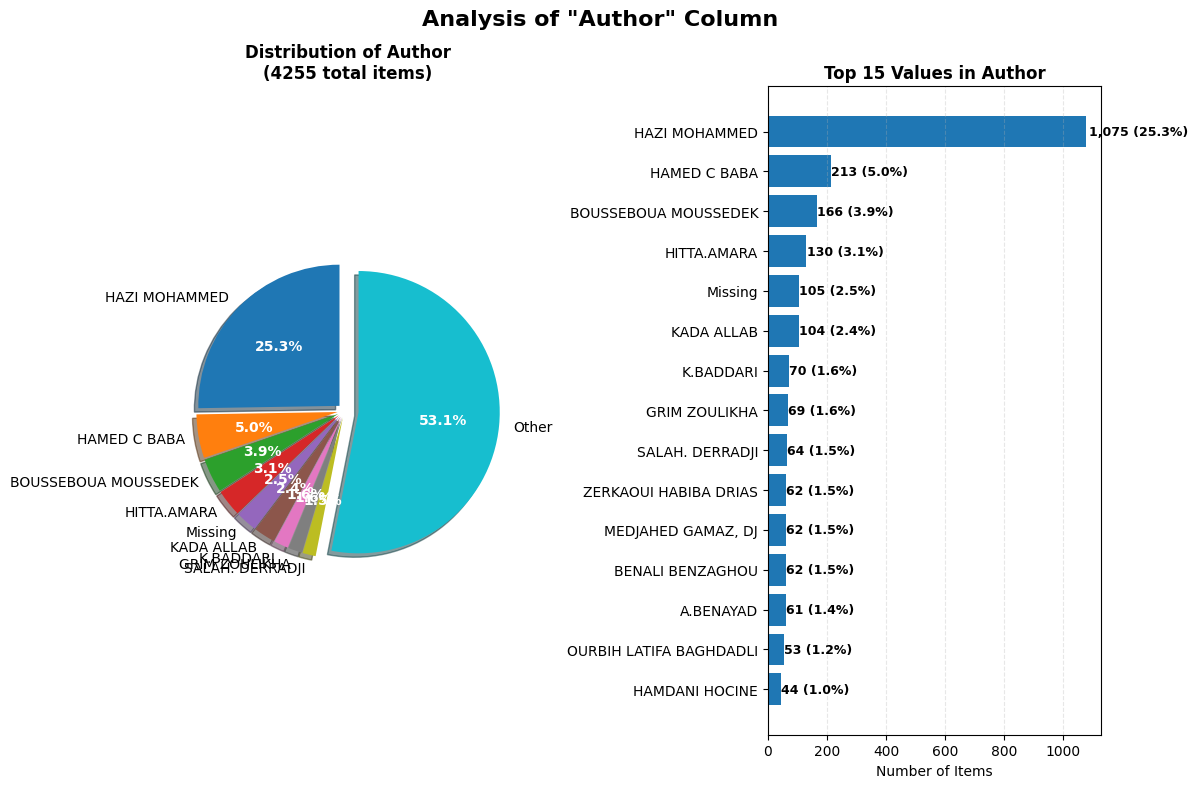

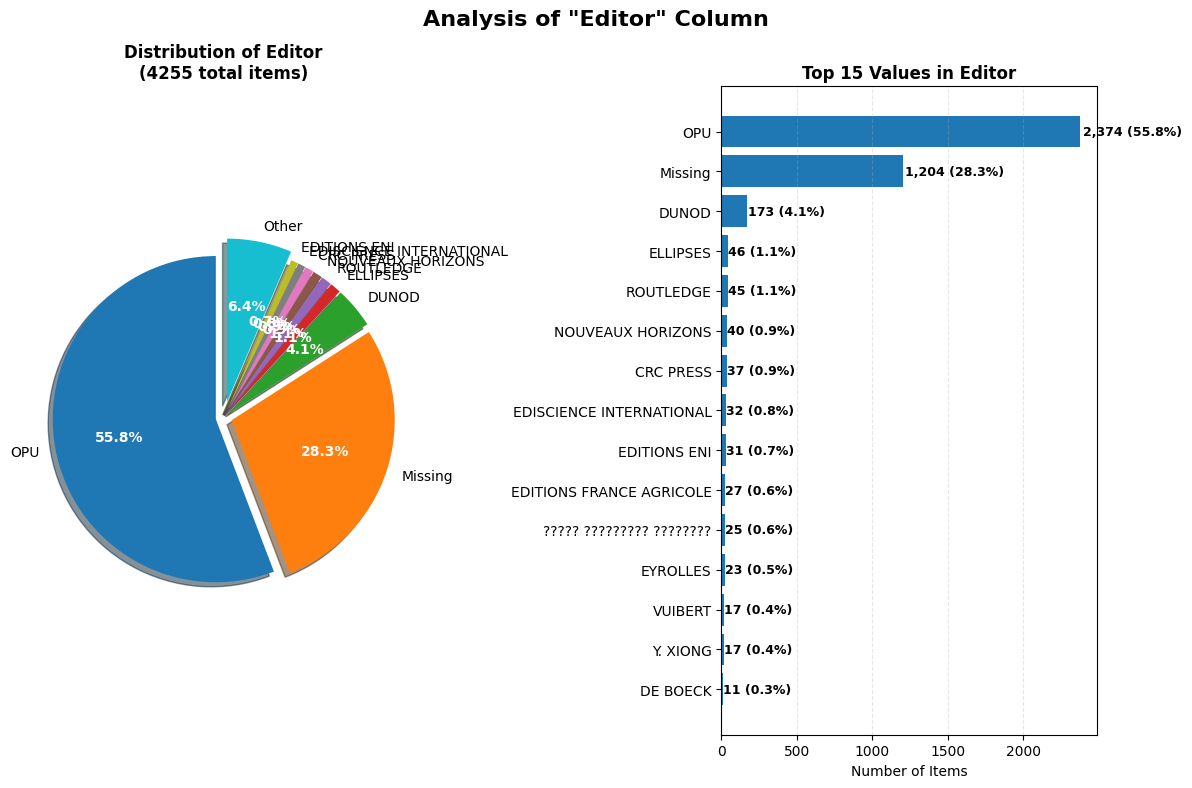

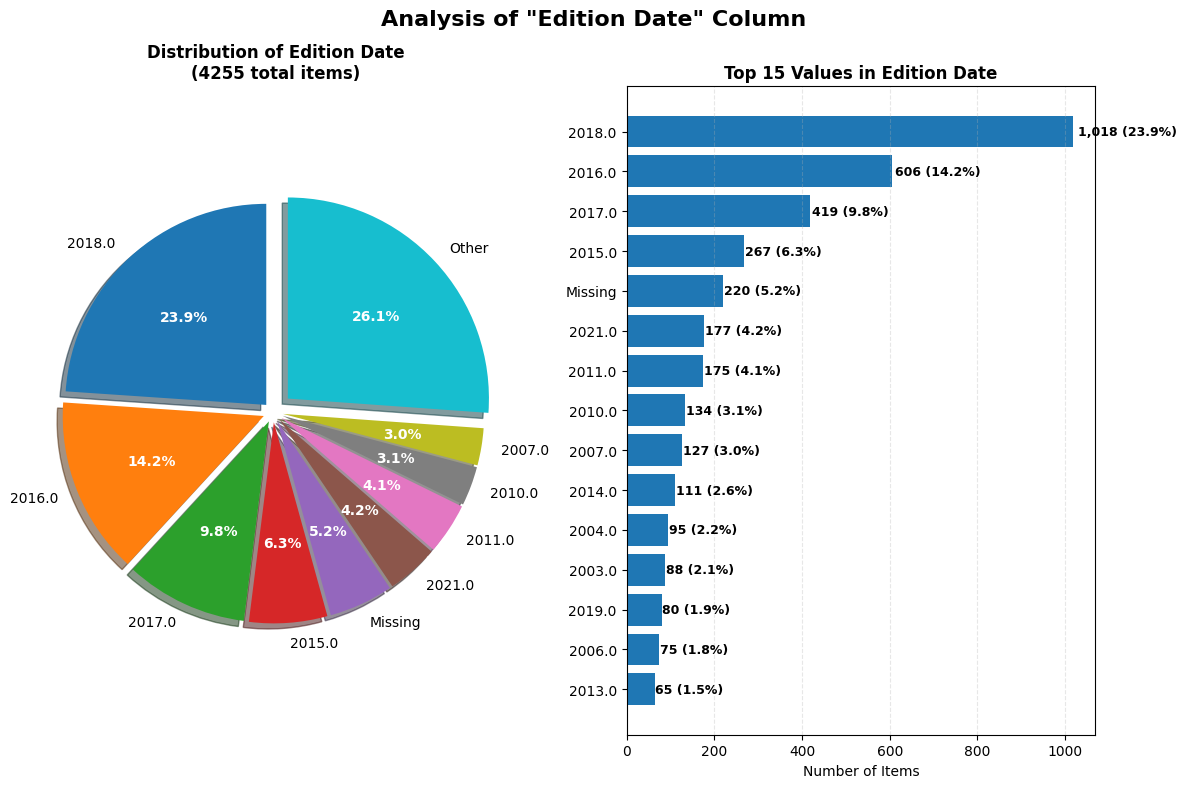

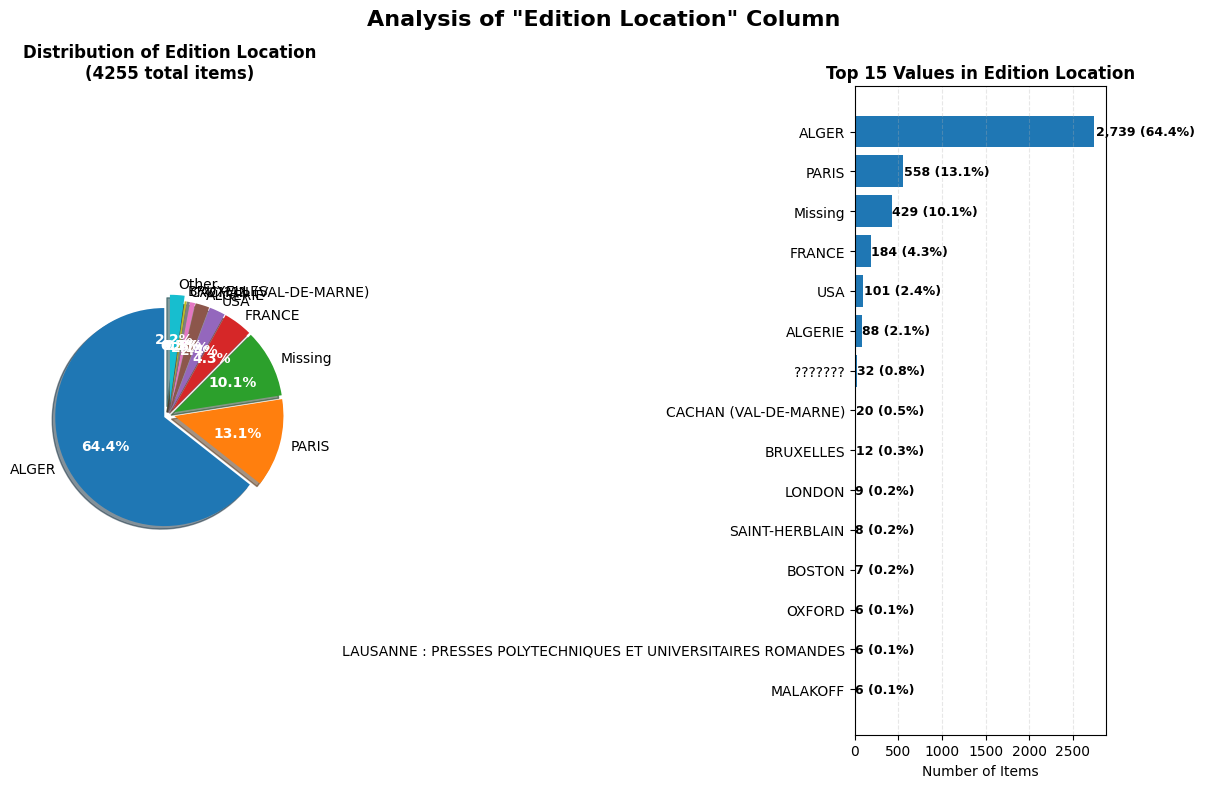

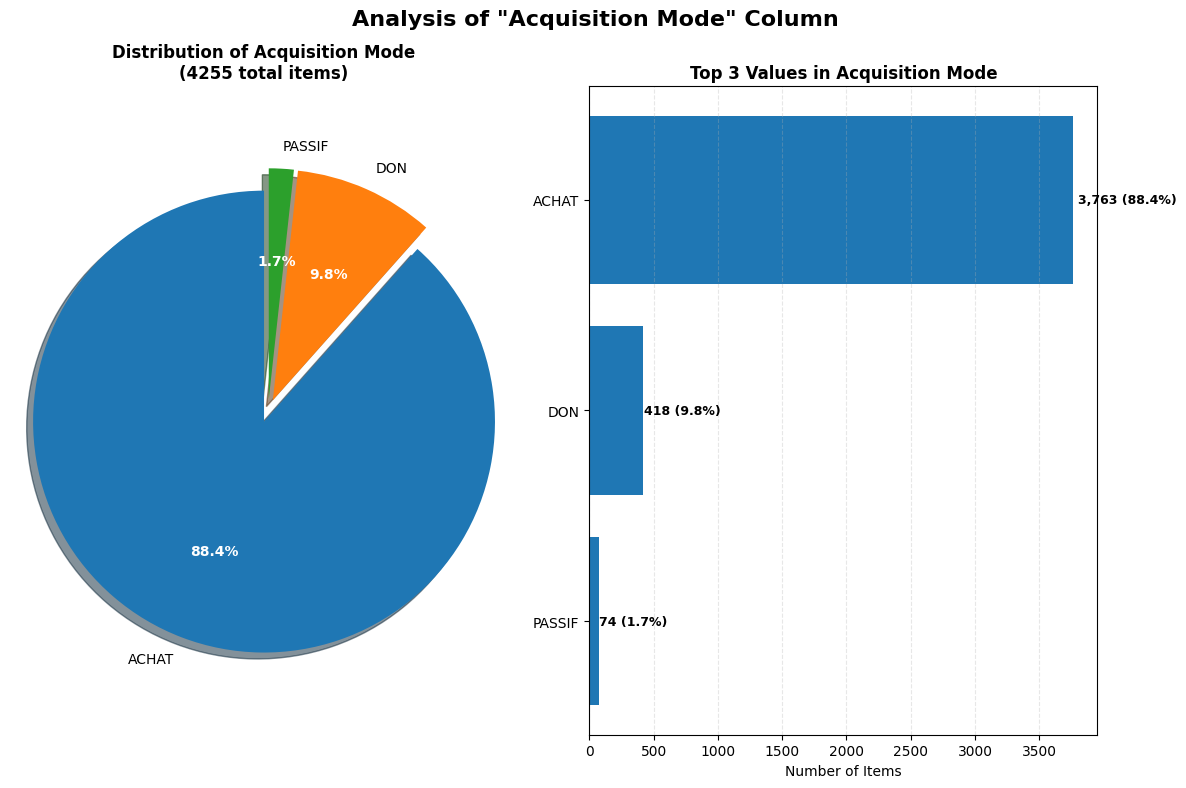

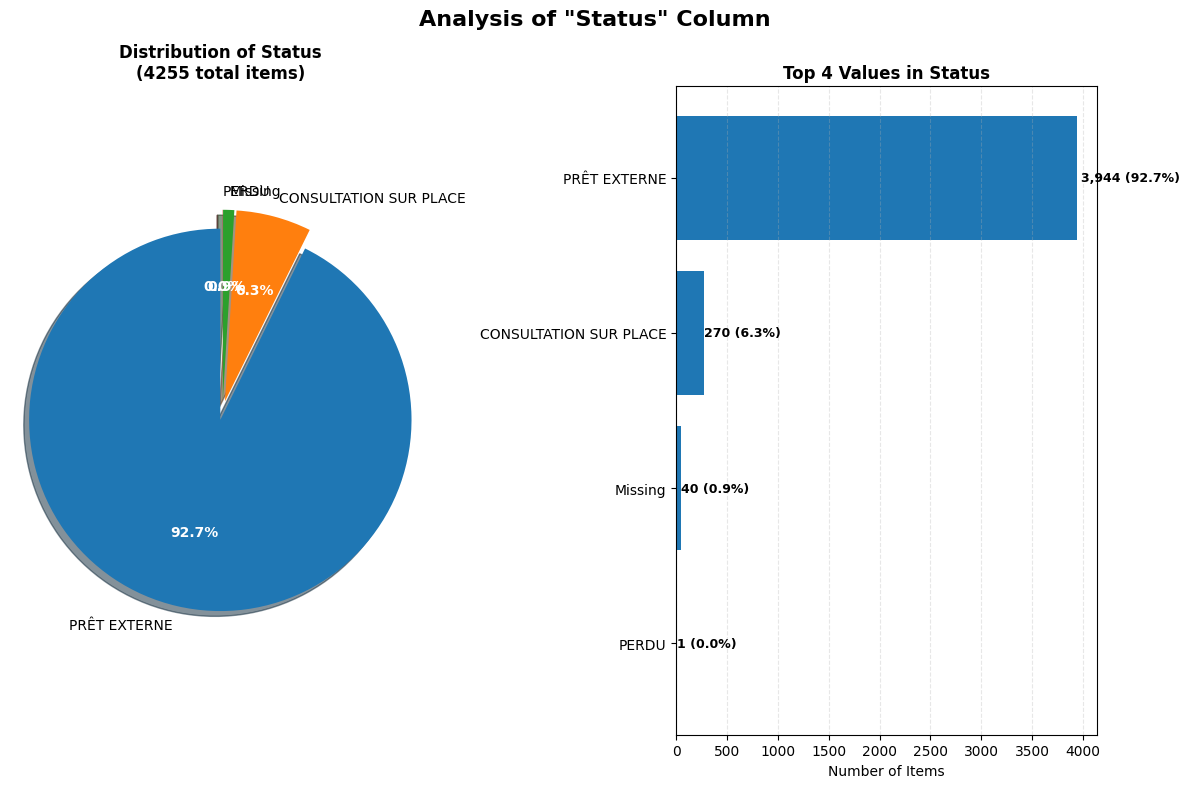

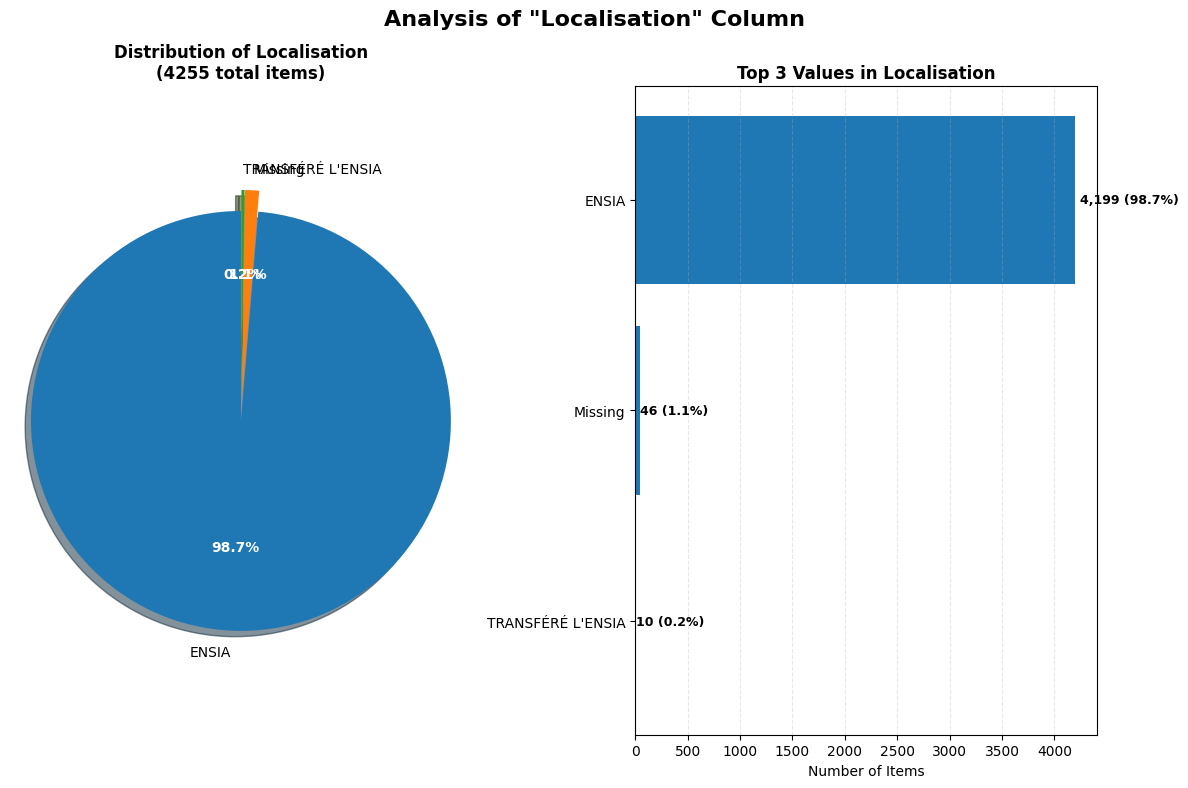

In [17]:
for column in preproc_library_inv.columns:

    # Skip the title and inv number columns (theyre unique)
    if column in {'Inventory Number','Title'}:
        continue

    visualize_unique_values(preproc_library_inv,column)

In [18]:
TempCSVFile(preproc_library_inv)
MissingValueSummary(preproc_library_inv)

Data exported to: C:\Users\mustapha\AppData\Local\Temp\tmpvghtgl68.csv
Number of instances = 4255

Missing Values Summary:
          Column  Missing_Values Percent_Missing
Inventory Number               0           0.00%
           Title               0           0.00%
          Author             105           2.47%
          Editor            1204          28.30%
    Edition Date             220           5.17%
Edition Location             429          10.08%
Acquisition Mode               0           0.00%
          Status              40           0.94%
    Localisation              46           1.08%


### Insight gained from the gifted books and their editors

In [19]:
editor_analysis = preproc_library_inv['Editor'].isna().groupby(
    preproc_library_inv['Acquisition Mode']
).mean() * 100

print("Missing Editor % by Acquisition Mode:")
print(editor_analysis)

Missing Editor % by Acquisition Mode:
Acquisition Mode
ACHAT     27.345203
DON       36.842105
PASSIF    28.378378
Name: Editor, dtype: float64


## Remove rows filled with '???'

In [20]:
# Remove rows where ANY column contains "???"
mask = preproc_library_inv.apply(lambda row: row.astype(str).str.contains('\?\?\?').any(), axis=1)
preproc_library_inv = preproc_library_inv[~mask]

print(f"Removed {mask.sum()} rows containing '???'")

Removed 79 rows containing '???'


## Replacing Missing Values                 

### Status & Localisation

We use the most observed values ( >90% of observations )

In [21]:
preproc_library_inv['Status'] = preproc_library_inv['Status'].fillna('PRÊT EXTERNE')
preproc_library_inv['Localisation'] = preproc_library_inv['Localisation'].fillna('ENSIA')

In [ ]:
preproc_library_inv = quick_fill_missing(preproc_library_inv, 'Title')
preproc_library_inv = fill_remaining_missing(preproc_library_inv)

# some books have '2021' as a edition location, we replace it with UNKNOWN_LOCATION and set 2021 as the edition date

# Create mask for rows where Edition Location is '2021'
mask = preproc_library_inv['Edition Location'] == '2021'

# Update both columns for these rows
preproc_library_inv.loc[mask, 'Edition Date'] = '2021'
preproc_library_inv.loc[mask, 'Edition Location'] = 'UNKNOWN_LOCATION'

print(f"Updated {mask.sum()} rows")

In [ ]:
MissingValueSummary(preproc_library_inv)
TempCSVFile(preproc_library_inv)

Number of instances = 4176

Missing Values Summary:
          Column  Missing_Values Percent_Missing
Inventory Number               0           0.00%
           Title               0           0.00%
          Author               0           0.00%
          Editor               0           0.00%
    Edition Date               0           0.00%
Edition Location               0           0.00%
Acquisition Mode               0           0.00%
          Status               0           0.00%
    Localisation               0           0.00%
Data exported to: C:\Users\fafao\AppData\Local\Temp\tmpo6s2wn64.csv


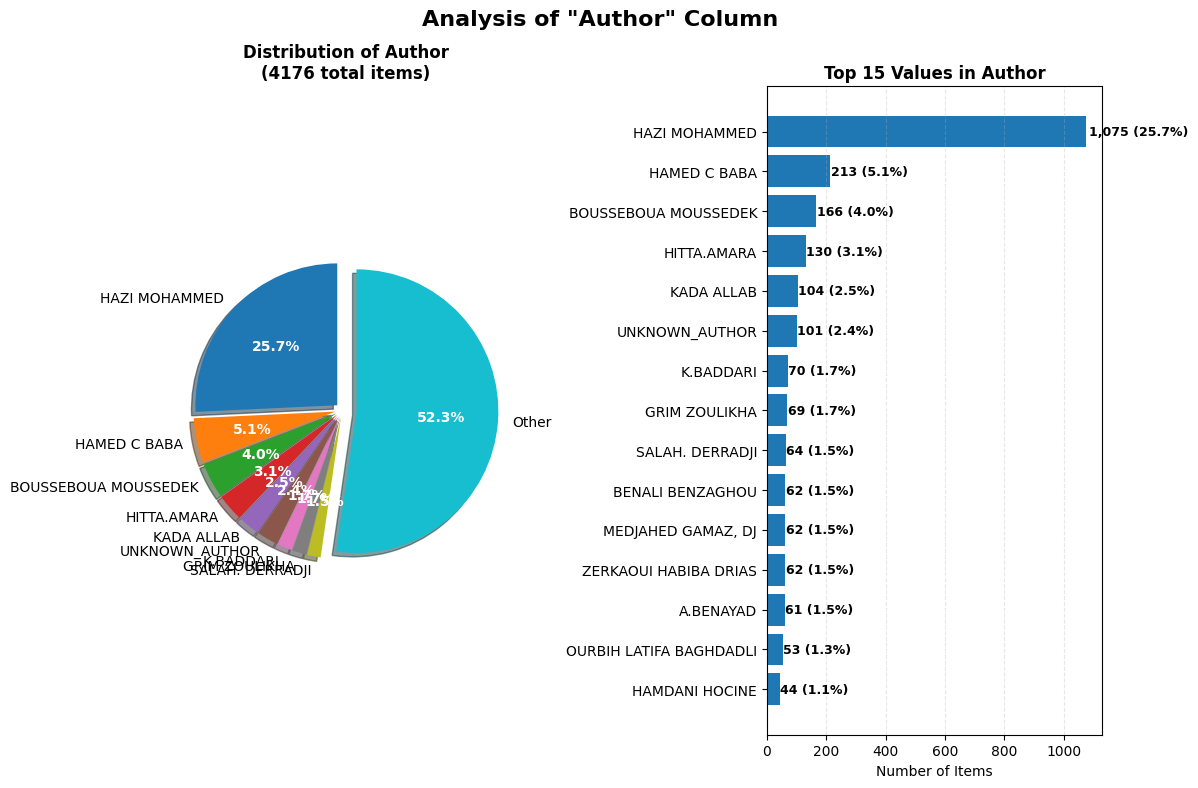

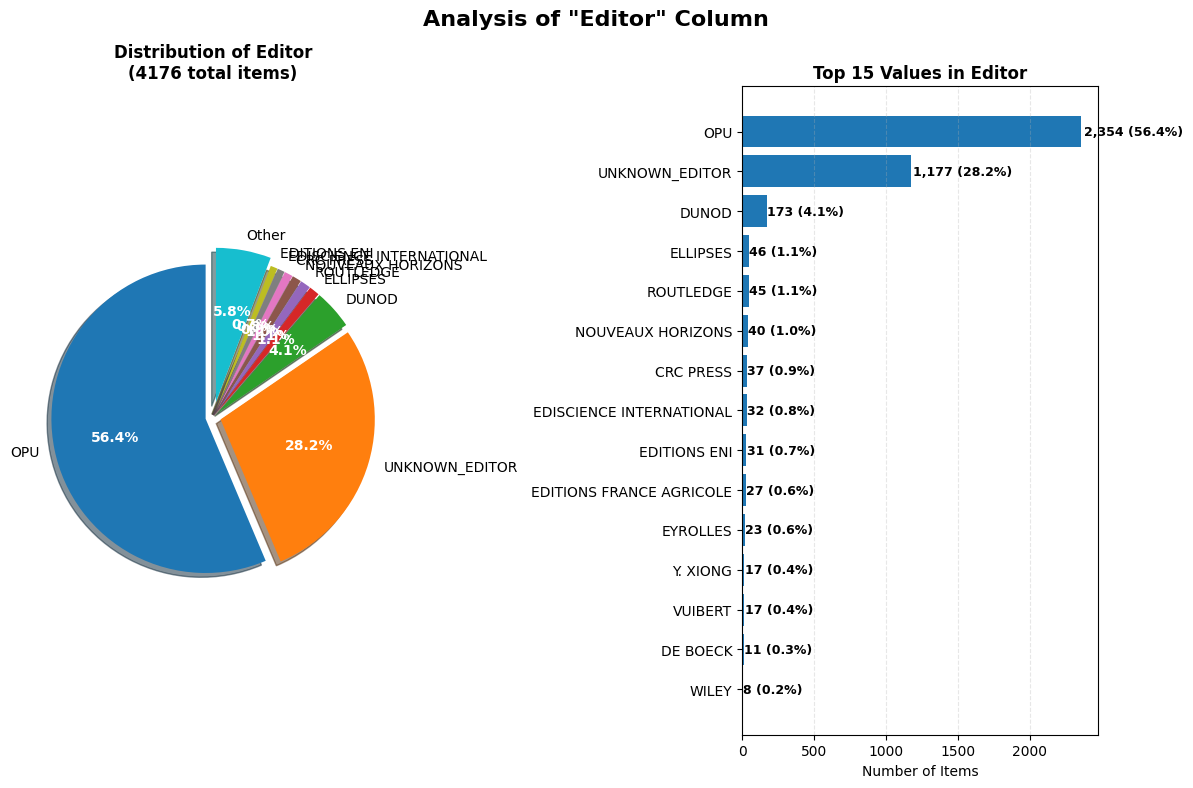

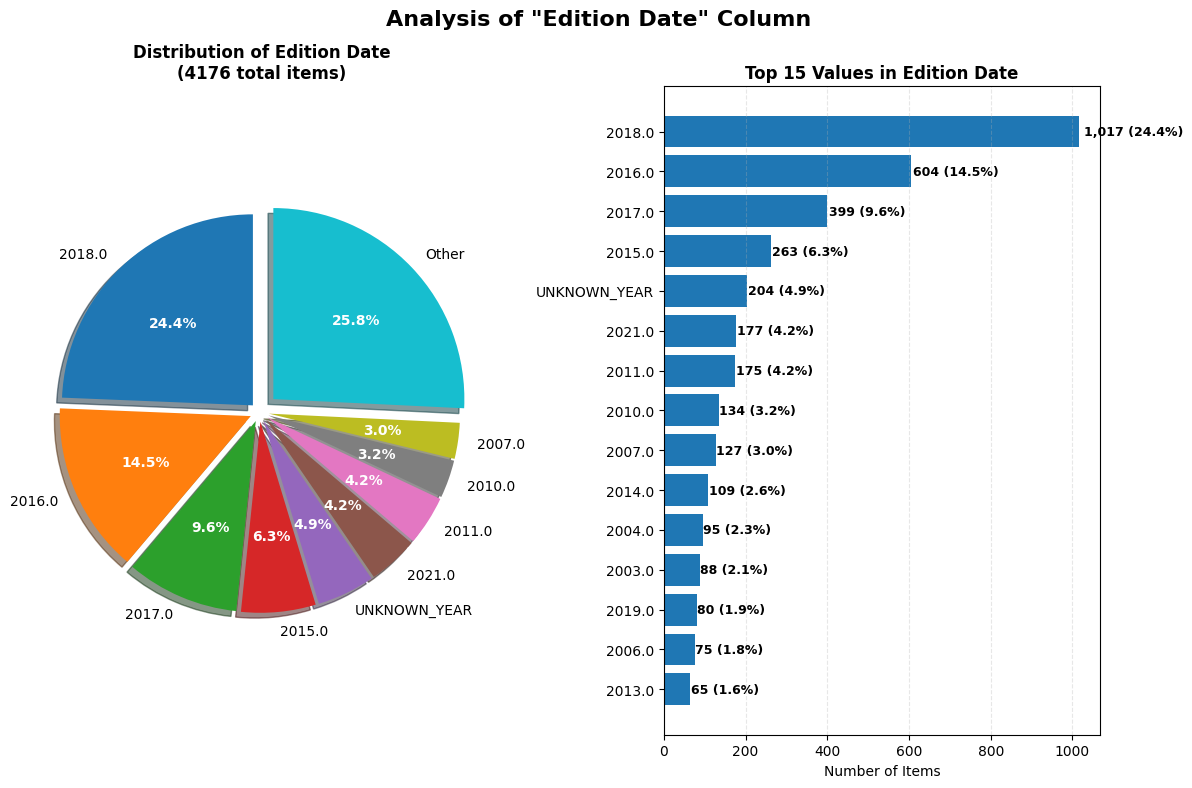

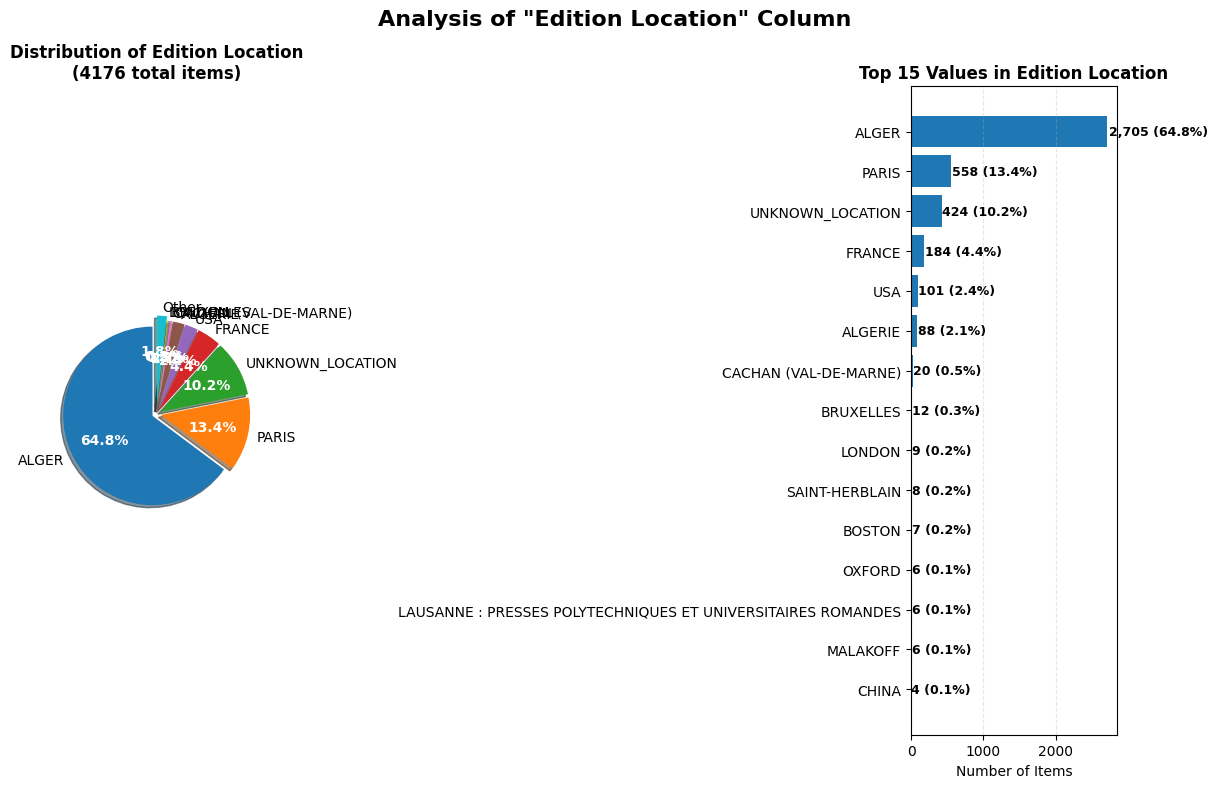

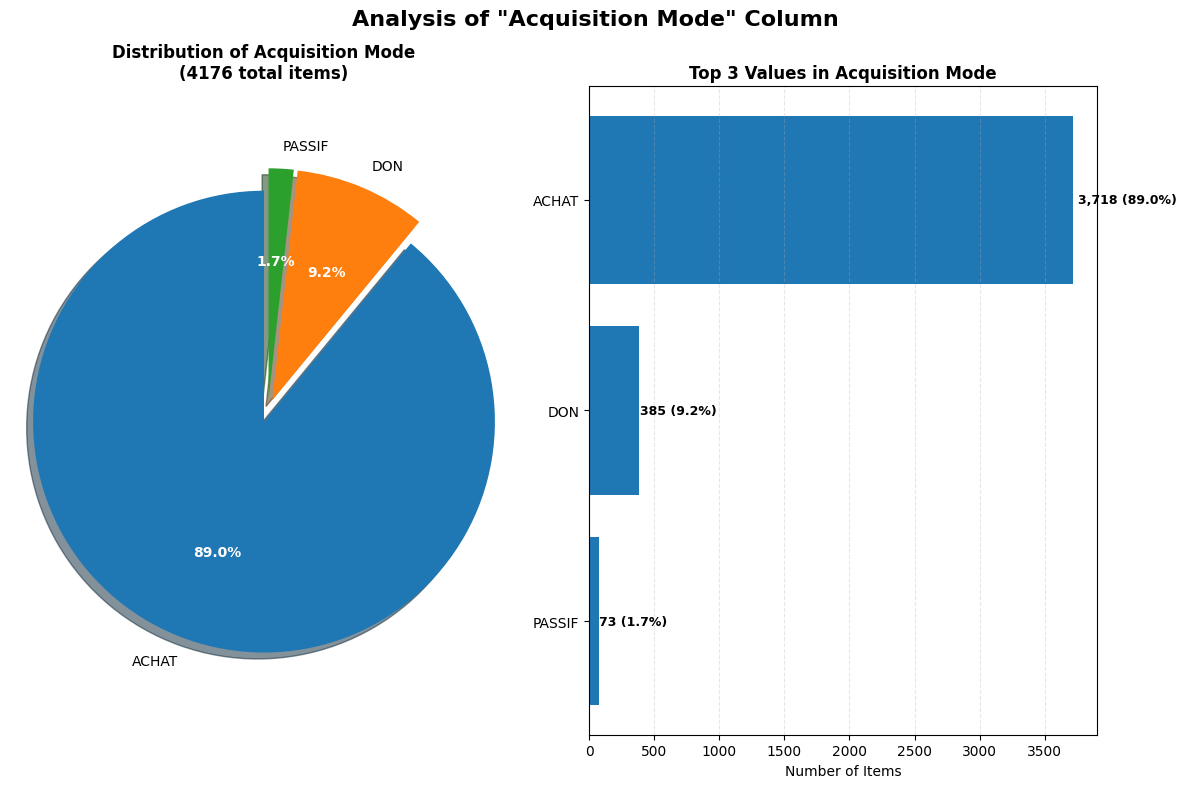

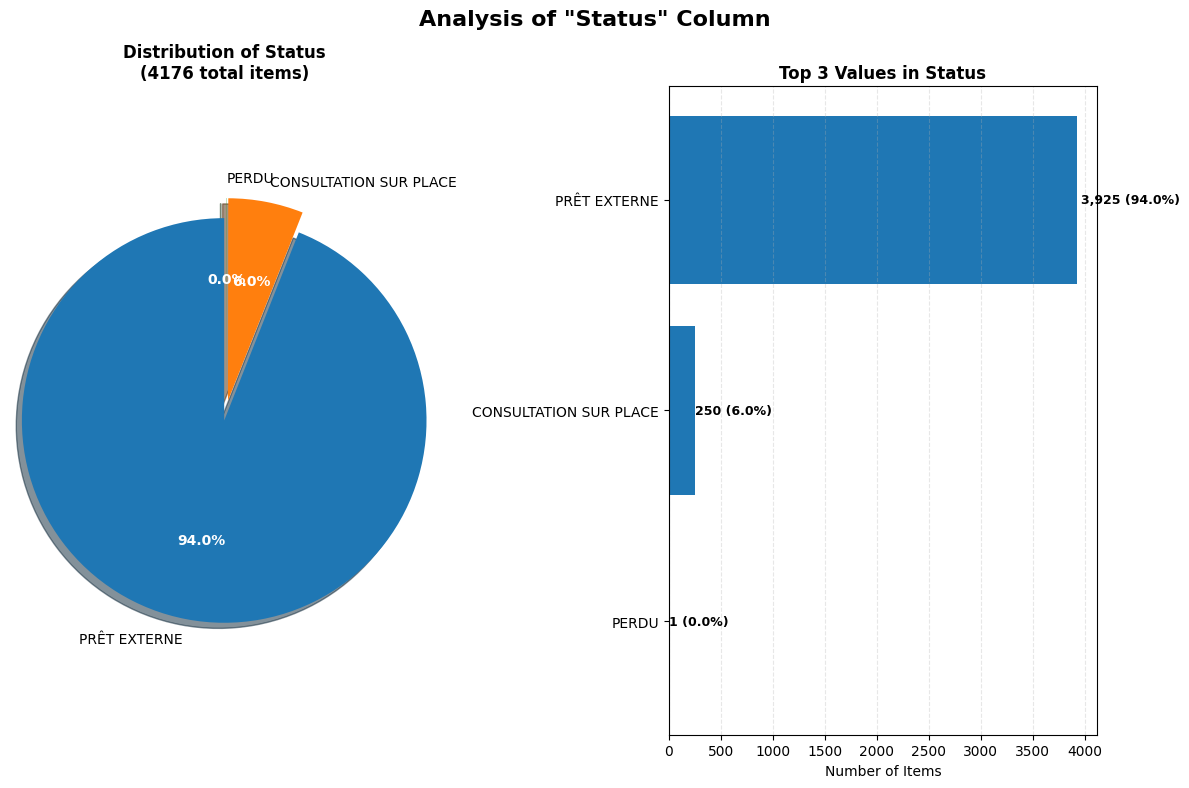

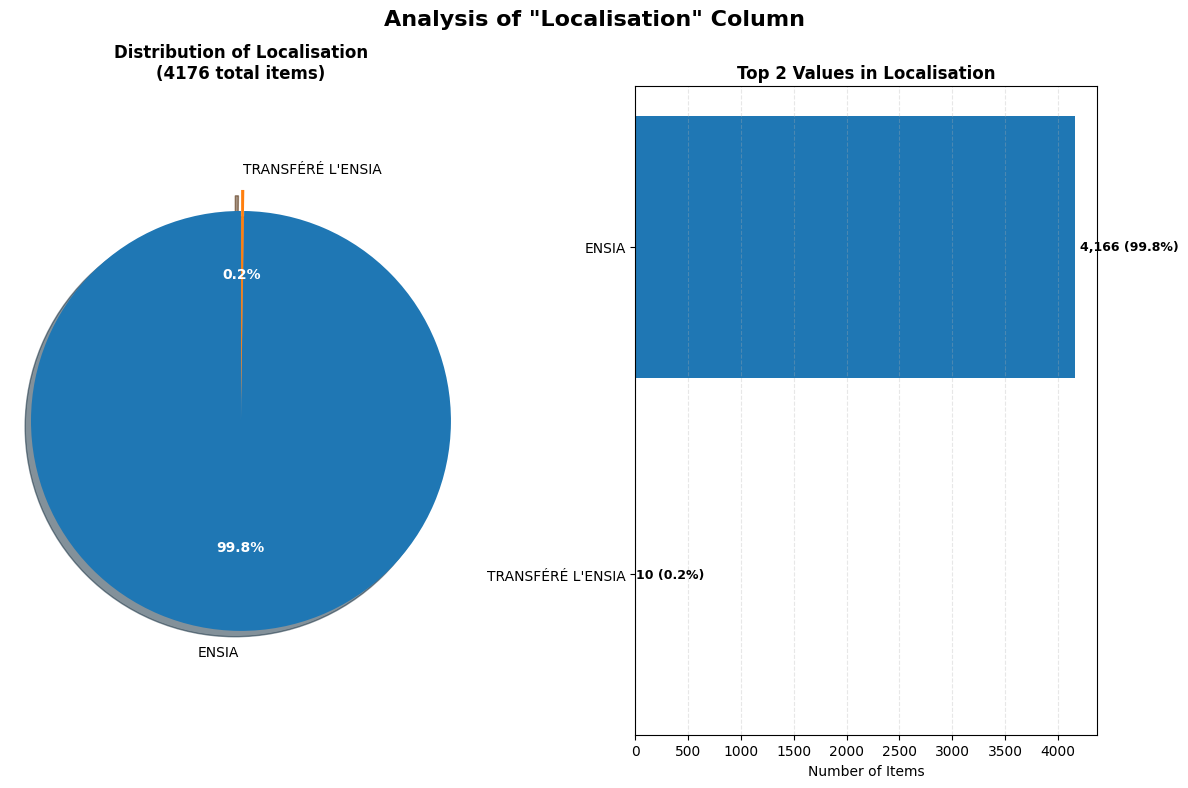

In [ ]:
for column in preproc_library_inv.columns:

    # Skip the title column (all titles are different)
    if column in {'Inventory Number','Title'}:
        continue

    visualize_unique_values(preproc_library_inv,column)

In [ ]:
# Export to specific path
file_path = r"../../data/processed/library_inventory.csv"  # Windows

preproc_library_inv.to_csv(file_path, index=False, encoding='utf-8')
print(f"Data exported to: {file_path}")

Data exported to: ../../data/processed/library_inventory.csv


## Sorting Rows Alphabetically Based On Title

In [ ]:
# Read the CSV file
df = pd.read_csv('../../data/processed/library_inventory.csv')

# Sort by 'Title' column
df = df.sort_values('Title')

# Save back to the same file
df.to_csv('../../data/processed/library_inventory.csv', index=False)